In [1]:
import numpy as np 
import pandas as pd 
import os
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.10.0


In [2]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))
tf.config.experimental.set_memory_growth(physical_devices[0], True)

Num GPUs Available:  1


In [3]:
# Create a list with the filepaths for training and testing
train_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test/Bangla_Food58_V2/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

In [4]:
test_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test/Bangla_Food58_V2/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

val_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test/Bangla_Food58_V2/valid')
val_filepaths = list(test_dir.glob(r'**/*.jpg'))

In [5]:
def image_processing(filepath):
    labels = [str(filepath[i]).split("\\")[-2] \
        for i in range(len(filepath))]
    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    df = pd.concat([filepath, labels], axis=1)
    df = df.sample(frac=1).reset_index(drop = True)
    return df

In [6]:
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)

In [7]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 23905

Number of different labels: 58

Labels: ['Chicken_wings' 'kebab - Gosht Kebab' 'Begun Bhorta'
 'Tundul ruti - Nan Ruti' 'Fried_rice' 'Momo' 'Chicken_curry' 'Doi'
 'Chicken_Grill' 'Burger' 'Mixed vegetable stir-fry - Torkari' 'Singgara'
 'Biriyani' 'French_fries' 'omelette' 'Chocolate_cake' 'pizza'
 'Vegetable fritters - Beguni' 'Shawarma' 'Lentil fritters - Dal Puri'
 'Sandwich' 'Fish Bhuna_Mach Bhuna' 'cheesecake' 'Noodles'
 'Lentil soup_Dal' 'Fuchka' 'ice_cream' 'Meat Curry_Gosht Bhuna' 'Borhani'
 'Boiled_egg' 'Cake' 'Shak-Vaji' 'Chitoi  Pitha' 'Alu Bhorta'
 'Begun Bhaja' 'Shemai' 'Jorda' 'Rosogolla' 'Falooda' 'Khichuri' 'Sondesh'
 'Salad' 'Kacchi' 'Hilsha_Fish_Curry' 'Shik_kabab' 'Rice' 'Misti'
 'Lal-shak-Vaji' 'Parata' 'Payesh-Firni' 'Alu-Vaji' 'Jalebi'
 'Fried chicken - Murg Bhaja' 'Vapa Pitha' 'Korola-Vaji'
 'Prawn curry - Chingri bhuna' 'Fried fish_Mach Bhaja' 'poached_egg']


In [8]:
train_df.head(58)

,Filepath,Label
0,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_wings
1,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,kebab - Gosht Kebab
2,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Begun Bhorta
3,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Tundul ruti - Nan Ruti
4,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Fried_rice
5,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_wings
6,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Momo
7,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_curry
8,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Doi
9,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_Grill


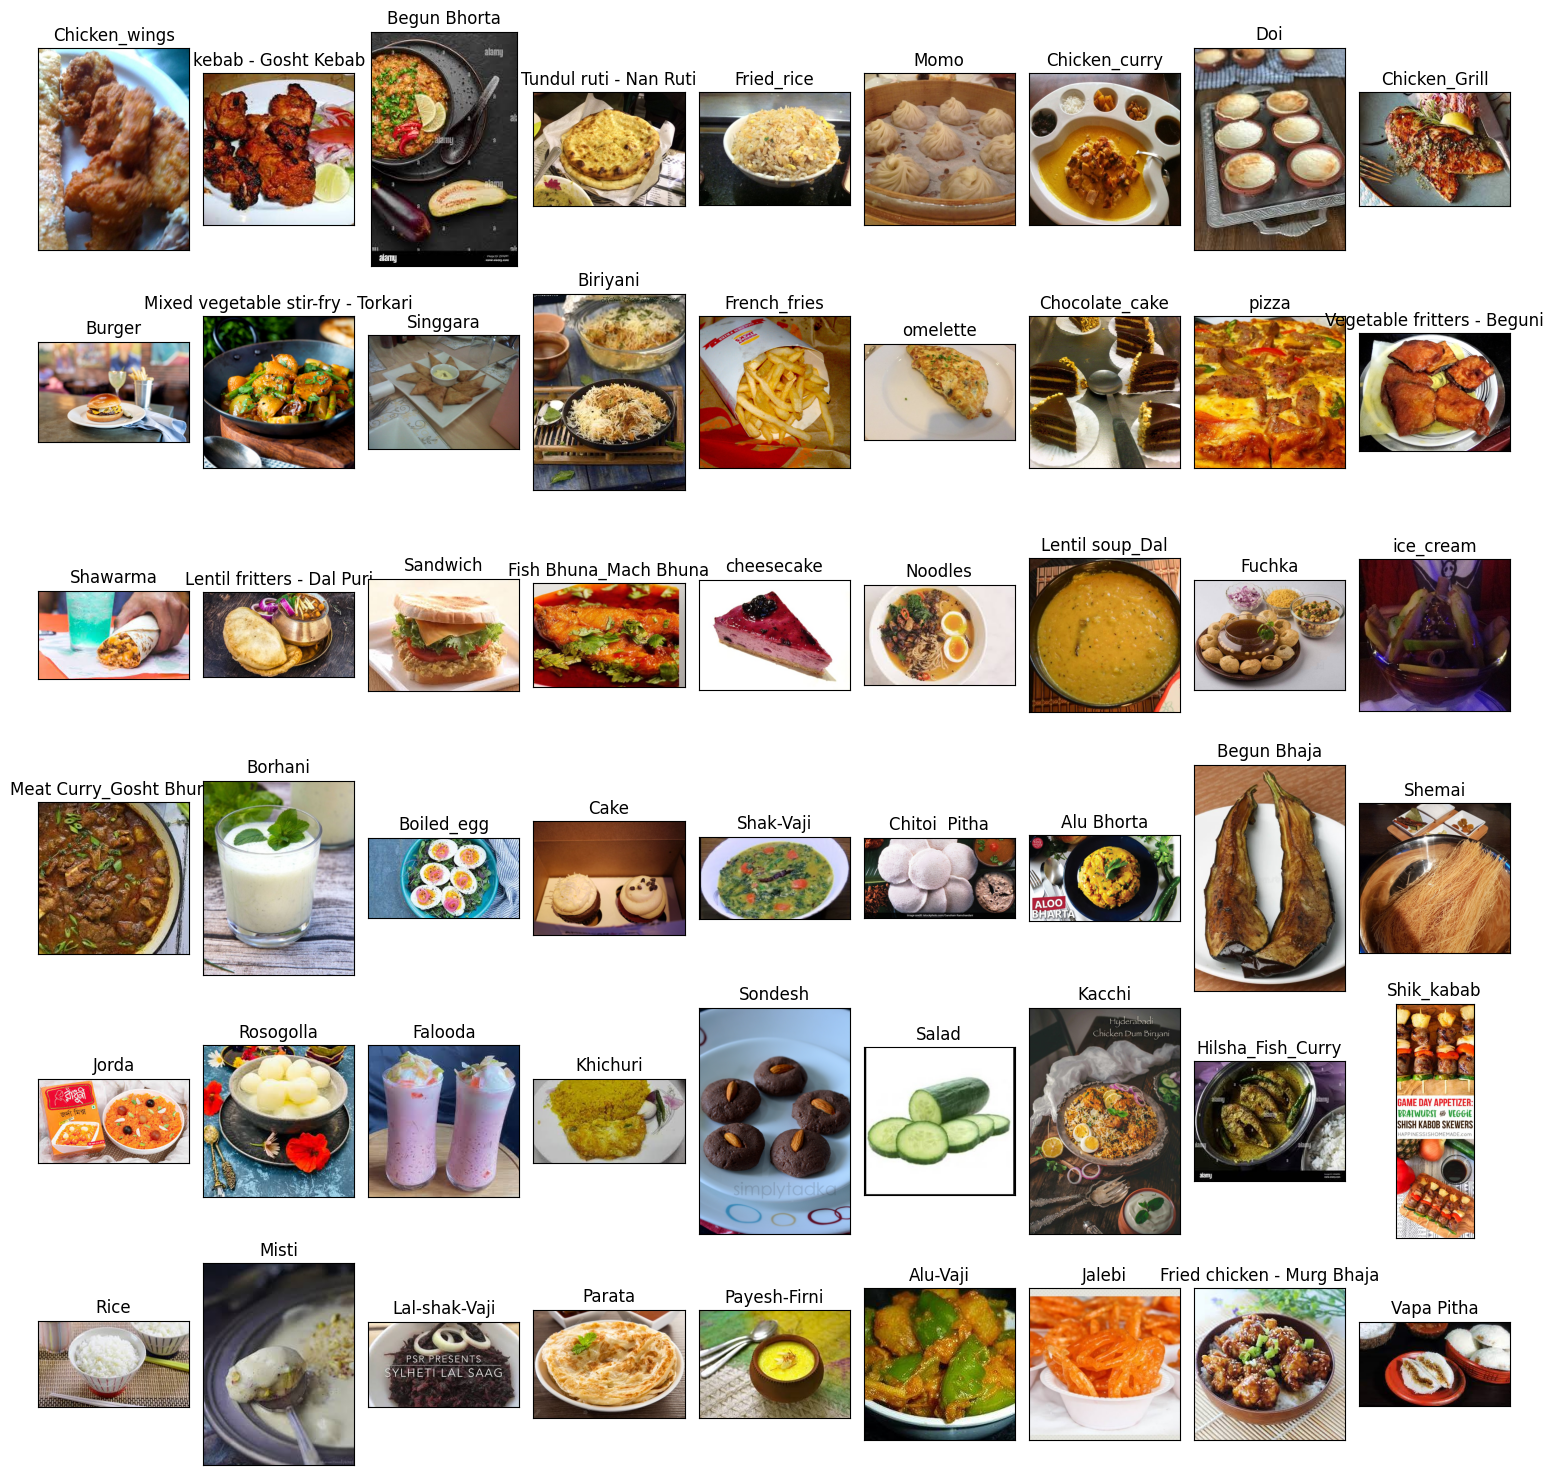

In [9]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=9,figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=1)
plt.show()

In [10]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [11]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 23905 validated image filenames belonging to 58 classes.


In [12]:
val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 286 validated image filenames belonging to 58 classes.


In [13]:
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 286 validated image filenames belonging to 58 classes.


In [14]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

In [15]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(58, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
748/748 [==============================] - 110s 141ms/step - loss: 1.3644 - accuracy: 0.6333 - val_loss: 1.4321 - val_accuracy: 0.5629
Epoch 2/15
748/748 [==============================] - 102s 136ms/step - loss: 0.7906 - accuracy: 0.7683 - val_loss: 1.2666 - val_accuracy: 0.6364
Epoch 3/15
748/748 [==============================] - 103s 137ms/step - loss: 0.6267 - accuracy: 0.8100 - val_loss: 1.1952 - val_accuracy: 0.6434
Epoch 4/15
748/748 [==============================] - 104s 139ms/step - loss: 0.5100 - accuracy: 0.8443 - val_loss: 1.2176 - val_accuracy: 0.6399
Epoch 5/15
748/748 [==============================] - 102s 137ms/step - loss: 0.4084 - accuracy: 0.8700 - val_loss: 1.2049 - val_accuracy: 0.6434
Epoch 6/15
748/748 [==============================] - 103s 137ms/step - loss: 0.3294 - accuracy: 0.8960 - val_loss: 1.2795 - val_accuracy: 0.6643
Epoch 7/15
748/748 [==============================] - 103s 138ms/step - loss: 0.2655 - accuracy: 0.9140 - val_loss: 1.3389 -

In [16]:
pretrained_model.trainable = True

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(pretrained_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in pretrained_model.layers[:fine_tune_at]:
  layer.trainable =  False

Number of layers in the base model:  155


In [17]:
history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/15
748/748 [==============================] - 98s 131ms/step - loss: 0.0828 - accuracy: 0.9721 - val_loss: 2.2672 - val_accuracy: 0.6573
Epoch 2/15
748/748 [==============================] - 94s 126ms/step - loss: 0.0730 - accuracy: 0.9751 - val_loss: 2.5318 - val_accuracy: 0.6434
Epoch 3/15
748/748 [==============================] - 95s 126ms/step - loss: 0.0718 - accuracy: 0.9758 - val_loss: 2.2385 - val_accuracy: 0.6818
Epoch 4/15
748/748 [==============================] - 95s 127ms/step - loss: 0.0736 - accuracy: 0.9745 - val_loss: 2.7290 - val_accuracy: 0.6643
Epoch 5/15
748/748 [==============================] - 96s 128ms/step - loss: 0.0577 - accuracy: 0.9812 - val_loss: 2.8232 - val_accuracy: 0.6538
Epoch 6/15
748/748 [==============================] - 95s 127ms/step - loss: 0.0902 - accuracy: 0.9700 - val_loss: 2.7600 - val_accuracy: 0.6888
Epoch 7/15
748/748 [==============================] - 95s 126ms/step - loss: 0.0574 - accuracy: 0.9813 - val_loss: 2.5786 - val_ac

In [18]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred1 = [labels[k] for k in pred]
pred1

9/9 [==============================] - 2s 133ms/step


['omelette',
 'Singgara',
 'Chocolate_cake',
 'Doi',
 'Salad',
 'cheesecake',
 'Khichuri',
 'Singgara',
 'Chocolate_cake',
 'cheesecake',
 'Chocolate_cake',
 'Lentil soup_Dal',
 'Sondesh',
 'Chocolate_cake',
 'Jorda',
 'Salad',
 'Boiled_egg',
 'Mixed vegetable stir-fry - Torkari',
 'Fried chicken - Murg Bhaja',
 'Sondesh',
 'poached_egg',
 'Begun Bhorta',
 'Chicken_curry',
 'Sondesh',
 'French_fries',
 'Biriyani',
 'Mixed vegetable stir-fry - Torkari',
 'Alu Bhorta',
 'Chicken_curry',
 'Sondesh',
 'pizza',
 'Fried fish_Mach Bhaja',
 'Sondesh',
 'Shik_kabab',
 'Noodles',
 'cheesecake',
 'Shawarma',
 'Fried chicken - Murg Bhaja',
 'Chitoi  Pitha',
 'Mixed vegetable stir-fry - Torkari',
 'French_fries',
 'ice_cream',
 'Payesh-Firni',
 'Tundul ruti - Nan Ruti',
 'Cake',
 'Shawarma',
 'Fuchka',
 'Chitoi  Pitha',
 'Biriyani',
 'Begun Bhorta',
 'Begun Bhorta',
 'Fried_rice',
 'Mixed vegetable stir-fry - Torkari',
 'Lentil soup_Dal',
 'Shawarma',
 'Chitoi  Pitha',
 'Fried_rice',
 'Chicken_Gril

In [19]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

In [31]:
img = output(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test_Images/a.jpg')
img

1/1 [==============================] - 0s 26ms/step


'Fried_rice'

In [22]:
model.save('Food_FineTuned_V2.h5')